# Exploratory Data Analysis (EDA)

This notebook aims to get a general sensing of the fraud detection dataset. Through EDA, I should be able to identify flaws of the dataset. Common issues of data include

- Duplicates
- Missing values
- Skewness
- Outliers
- Incorrect Data Type
- Unstandardised String Values
- Class imbalance

As such, this notebook will not only help me understand the data itself, but also flaws of the dataset, so that I can take actionable steps to resolve them, e.g. class imbalance will require undersampling / oversampling methods for high performance ML models.


## 0. Import Libraries


In [1]:
# Data Analysis Libraries
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Data Visualization Libraries
import sweetviz as sv

%matplotlib inline

# Self-Made Modules
import src.data_preprocess as dp
import src.eda_helpers as eda

print(f"Current pandas version: {pd.__version__}")

/Users/lunlun/Downloads/Github/Fraud-Detection-ML/.venv/lib/python3.12/site-packages/sweetviz/graph.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


Current pandas version: 2.0.3


## 1. Variables Description

- **Time**: Number of seconds elapsed between this transaction and the first transaction in the dataset
- **V1-V28**: Result of a PCA Dimensionality reduction to protect user identities and sensitive features
- **Amount**: Transaction amount
- **Class**: 1 for fraudulent transactions, 0 otherwise


## 2. Basic Summary Statistics


### Data Loading


In [2]:
df2 = pd.read_csv("data/raw/creditcard.csv")
df2.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Dataset Shape Inspection


In [3]:
print(f"Number of Rows: {df2.shape[0]}")
print(f"Number of Columns: {df2.shape[1]}")

Number of Rows: 284807
Number of Columns: 31


### Dataset Information


In [4]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

### Summary Statistics


In [5]:
pd.set_option("display.max_columns", None)
df2.describe(include="all")

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,2.239053e-15,1.673327e-15,-1.247012e-15,8.190001e-16,1.207294e-15,4.887456e-15,1.437716e-15,-3.772171e-16,9.564149e-16,1.039917e-15,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
df3 = df2

### What did I learn about Dataset?

The dataset consists of 284807 credit card transactions in September 2013 by European cardholders, with 31 columns (with V1-V28 anonymised features for sensitivity purposes). These anonymised features have been PCA-ed before. Other than these anonymised features, Time & Amount Transacted can be used as features for binary classification in this fraud detection problem. Target Variable is `Class` where models built should predict if a transaction belongs to fraud or not.


## 3. Automated HTML EDA Report (With `sweetviz`)

Having browsed through multiple data related articles to streamline my workflow for future projects, I chanced upon a tool that is extremely useful for EDA. `sweetviz` provides an efficient way to understand data, by generating an interactive reports, which highlight data types, with little coding effort. From the report, I can easily identify flaws in datasets like missing values, duplicates, class imbalance etc. I can also visualise the skewness of each individual column. This greatly expedites tedious EDA processes, and allow data scientists to reduce time-to-production for ML models. However, it is still needed for me to write seaborn / matplotlib code in order to gain more granular insights into our dataset.


In [7]:
# - Inspect Dataframe -
# df3 = spark.read.csv("data/raw/creditcard.csv", header=True, inferSchema=True)
print(f"Dataframe shape: {df3.count()}, {len(df3.columns)}")
df3.head()

Dataframe shape: Time      284807
V1        284807
V2        284807
V3        284807
V4        284807
V5        284807
V6        284807
V7        284807
V8        284807
V9        284807
V10       284807
V11       284807
V12       284807
V13       284807
V14       284807
V15       284807
V16       284807
V17       284807
V18       284807
V19       284807
V20       284807
V21       284807
V22       284807
V23       284807
V24       284807
V25       284807
V26       284807
V27       284807
V28       284807
Amount    284807
Class     284807
dtype: int64, 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
# - Pandas Profiling Report -
sweet_report = sv.analyze(df3, target_feat="Class", pairwise_analysis="on")
sweet_report.show_html("reports/sweet_report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report reports/sweet_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [9]:
df4 = df3

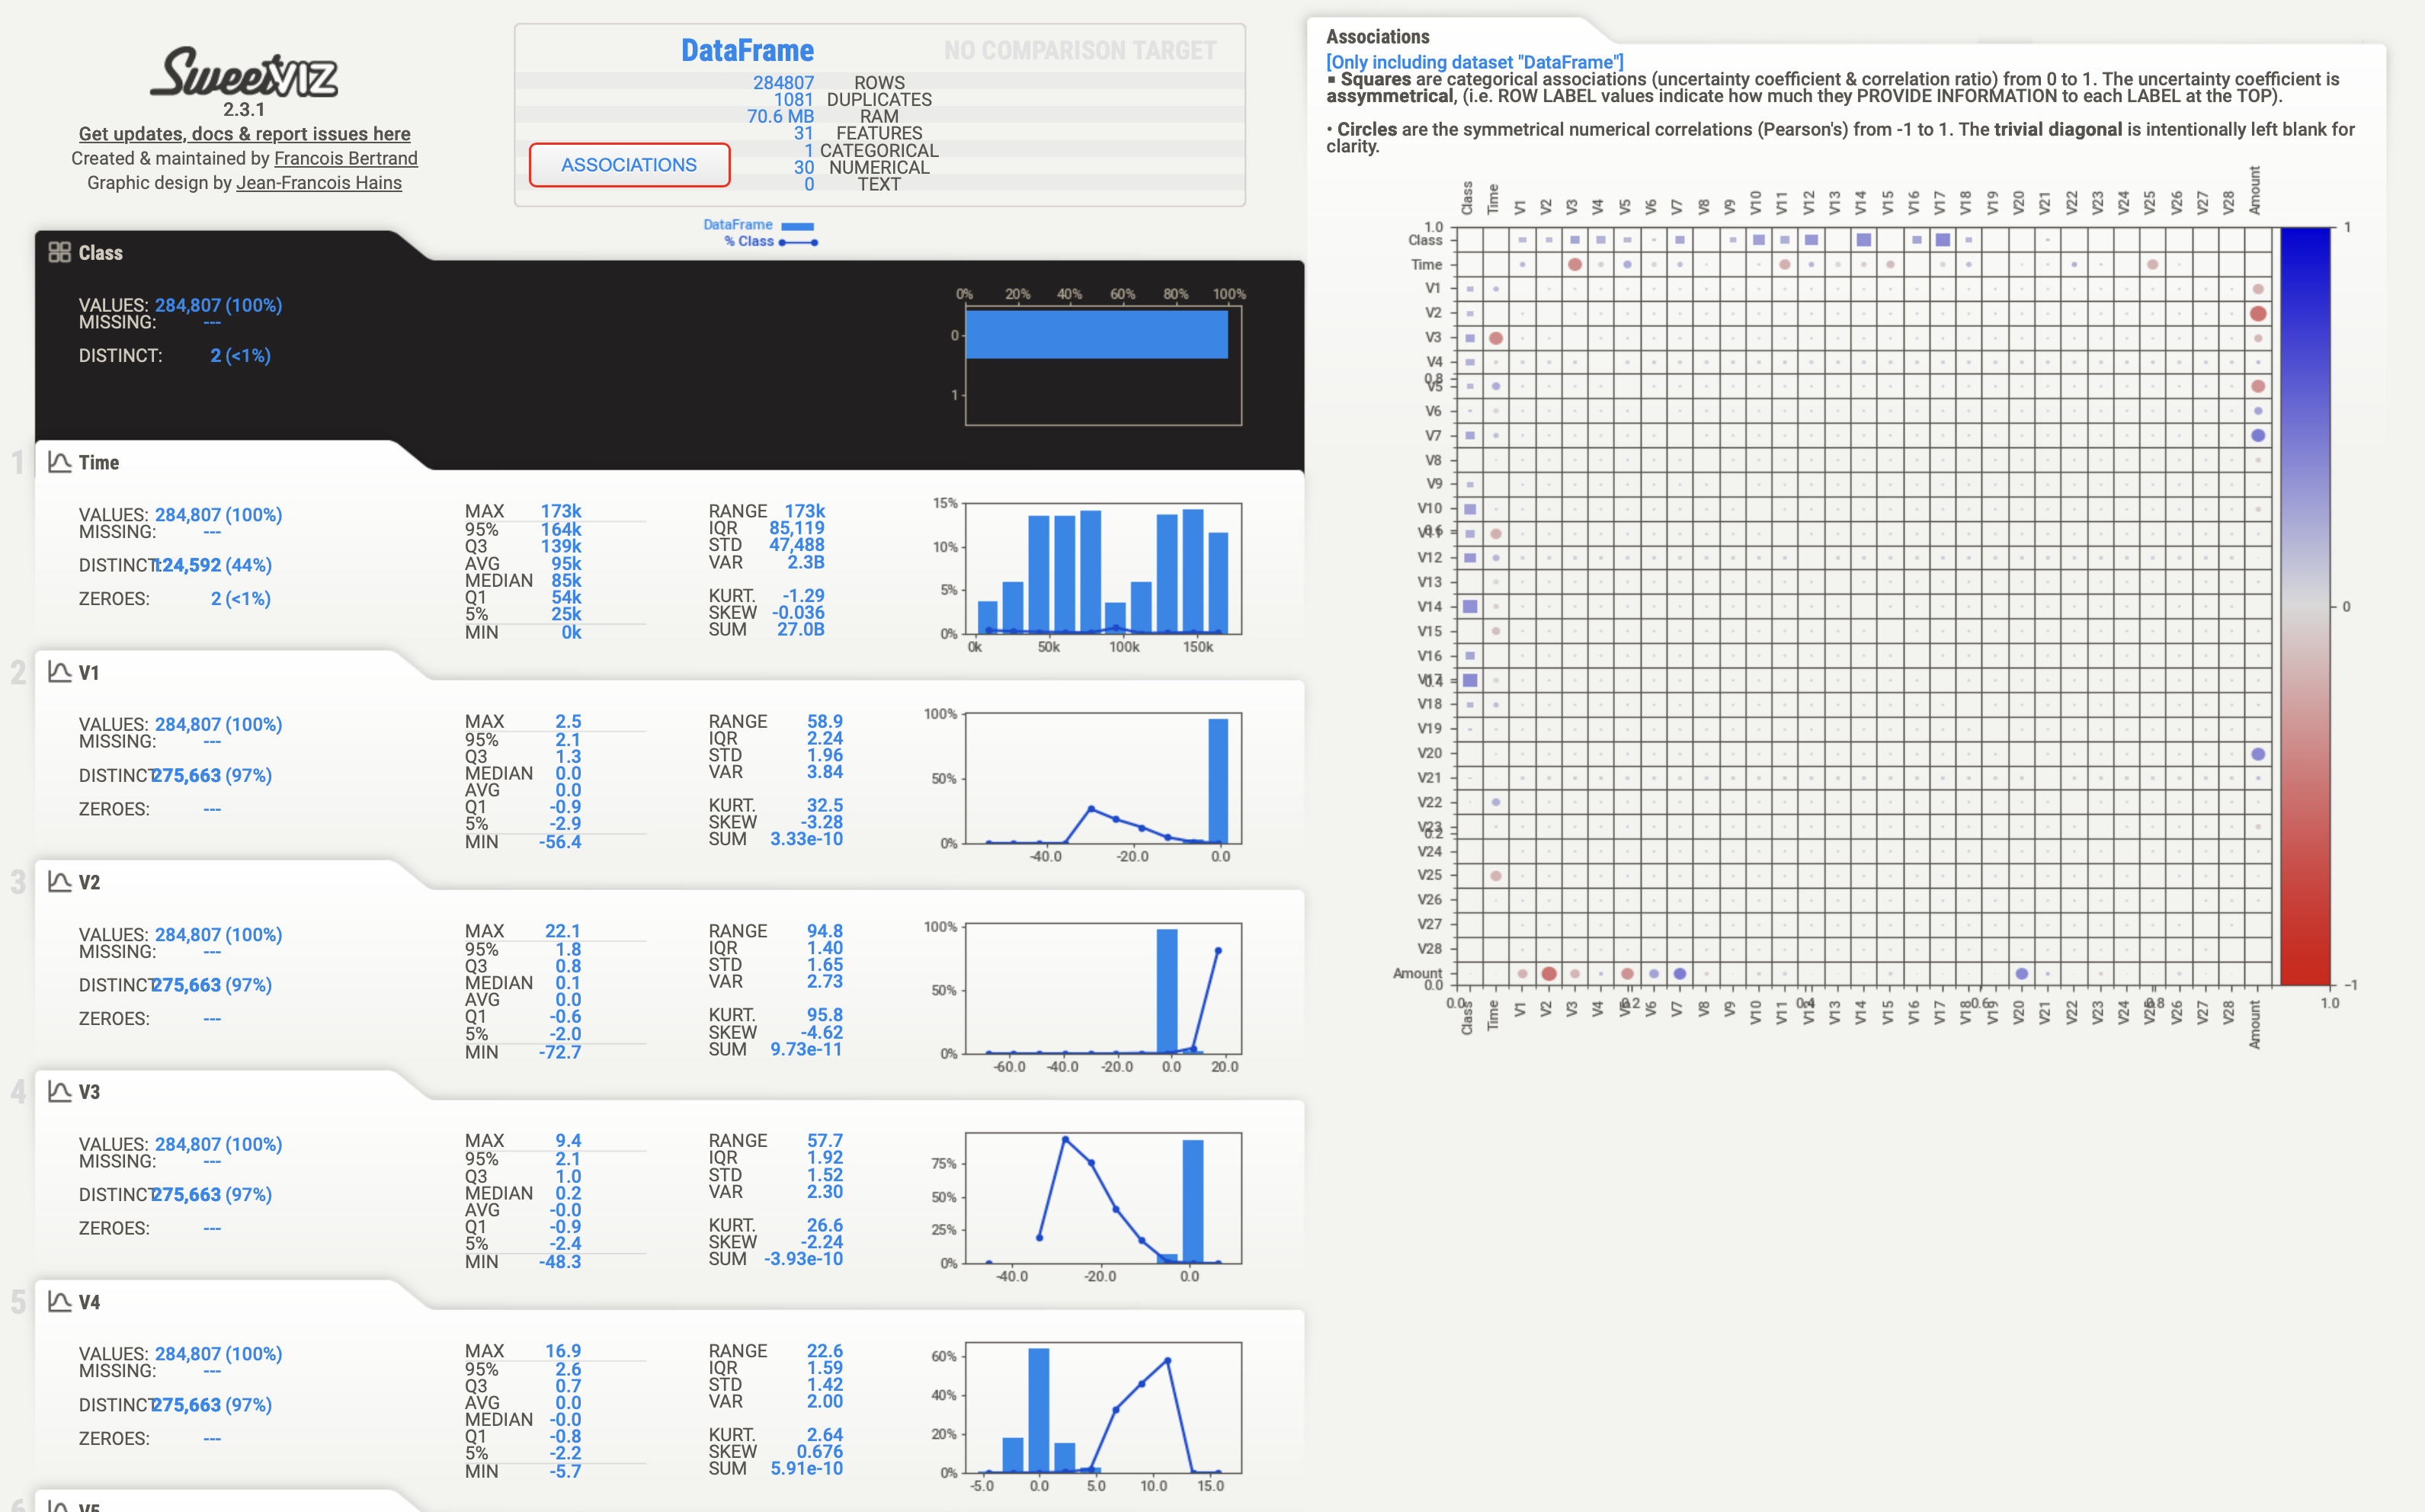


## 4. Manual EDA: Deeper Insights

It seems the `sweetviz` report doesn't highlight correlation issues properly despite manual configurations. Outliers & Skewness issues have to be coded manually as well. As such, to come up with the final list of issues in our dataset, let's generate subplots by seaborn & matplotlib.

### Correlation Issues

From the heatmap plot shown below, the maximum correlation between features is -0.53. Such a correlation is safe to handle usually, since Pearson correlations > 0.7 should be dealt with in normal cases. As such, we can safely conclude correlation is not an issue.


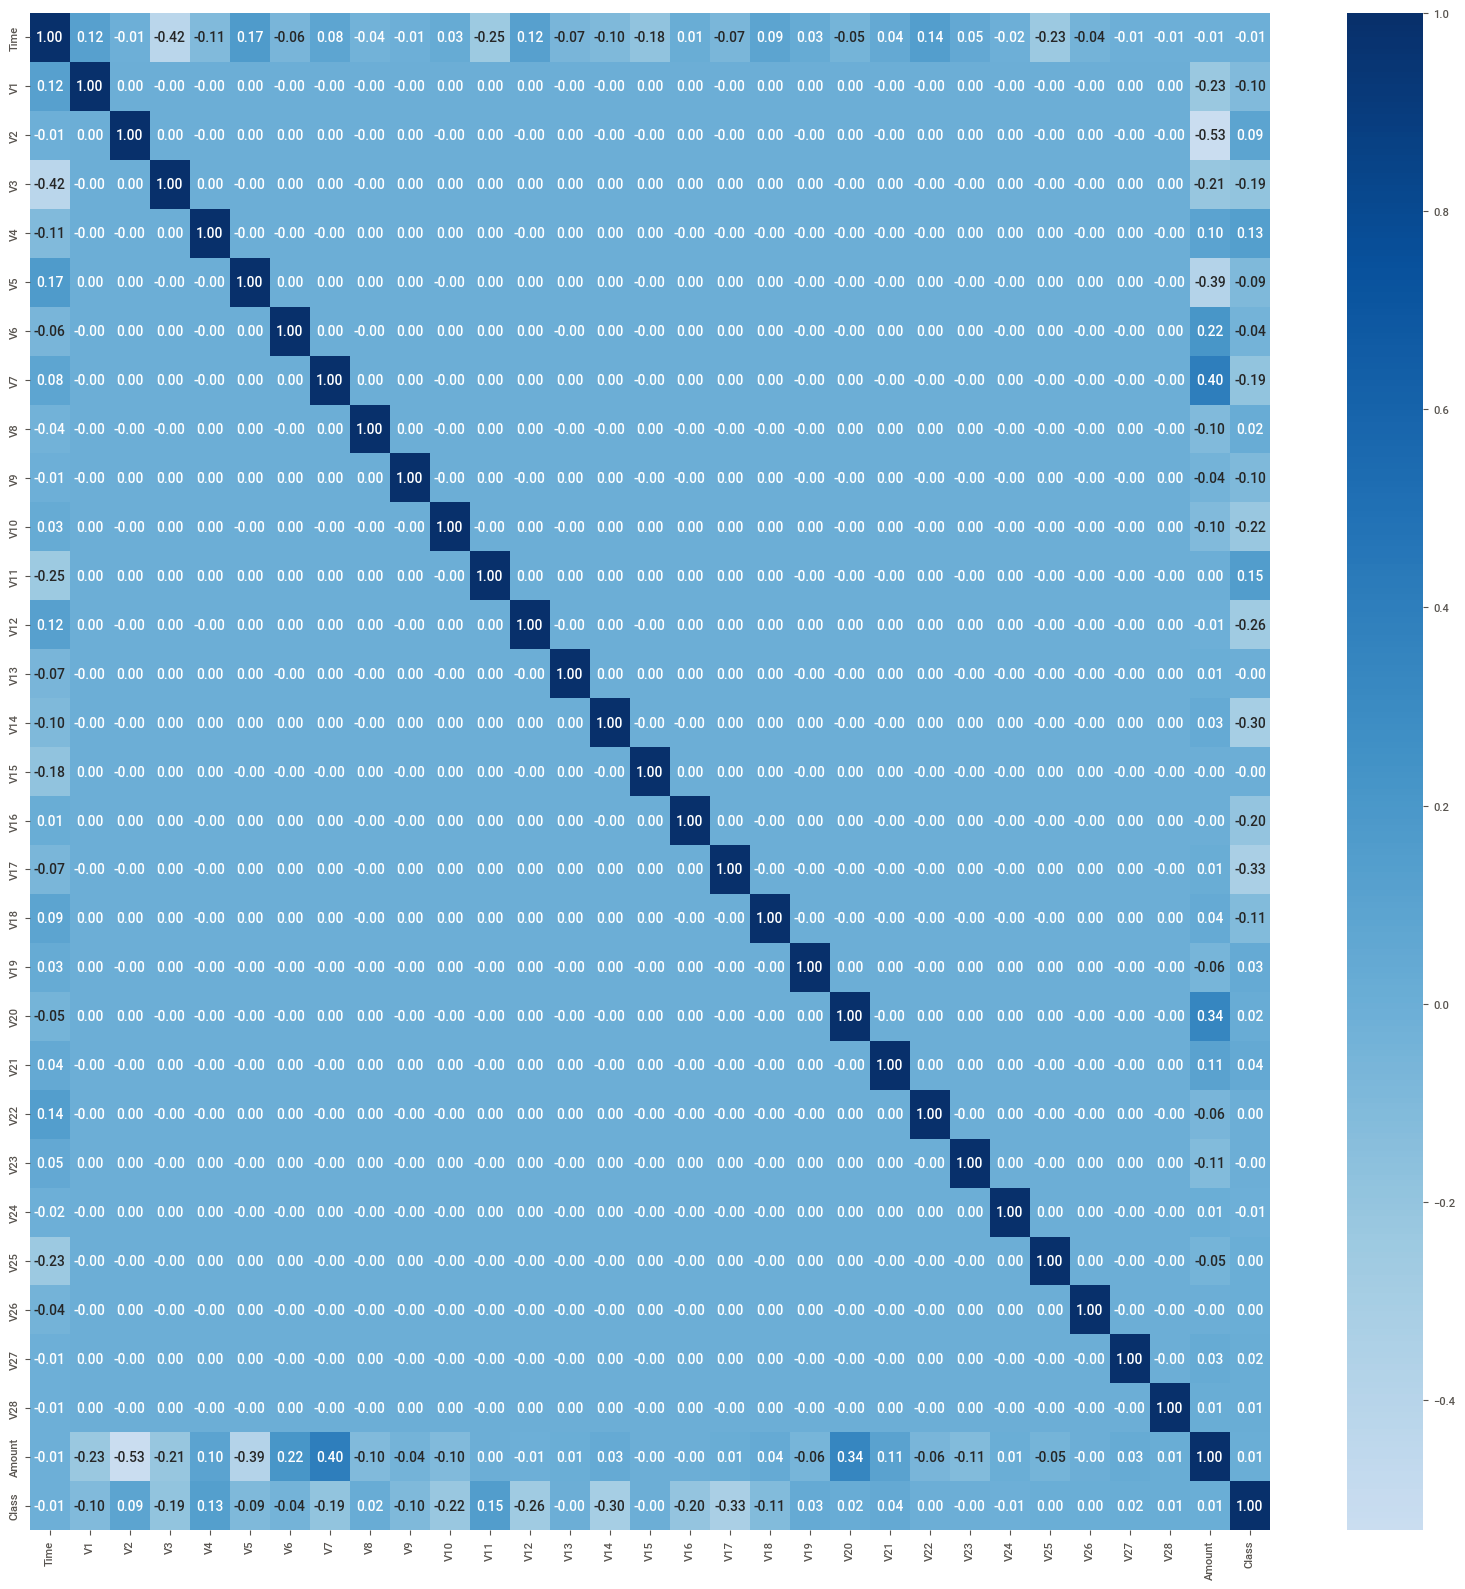

In [10]:
corr_matrix = df4.corr(numeric_only=True, method="pearson")  # 'pearson' is default
plt.figure(figsize=(16, 16))
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".2f", center=0)
plt.tight_layout()
plt.show()

### Outliers Detection


In [11]:
# - Inspect Outliers using IQR Method -
eda.OutlierAnalyser.inspect_outliers_iqr(df4)

,Column,Q1,Q3,Lower_Bound,Upper_Bound,Min,Max,Outlier_Count,Outlier_Pct
0,V27,-0.07,0.09,-0.31,0.33,-22.57,31.61,39163,13.75%
1,Amount,5.60,77.16,-101.75,184.51,0.00,25691.16,31904,11.2%
2,V28,-0.05,0.08,-0.25,0.28,-15.43,33.85,30342,10.65%
3,V20,-0.21,0.13,-0.73,0.65,-54.50,39.42,27770,9.75%
4,V8,-0.21,0.33,-1.01,1.13,-73.22,20.01,24134,8.47%
5,V6,-0.77,0.40,-2.52,2.15,-26.16,73.30,22965,8.06%
6,V23,-0.16,0.15,-0.63,0.61,-44.81,22.53,18541,6.51%
7,V12,-0.41,0.62,-1.94,2.15,-18.68,7.85,15348,5.39%
8,V21,-0.23,0.19,-0.85,0.81,-34.83,27.20,14497,5.09%
9,V14,-0.43,0.49,-1.80,1.87,-19.21,10.53,14149,4.97%


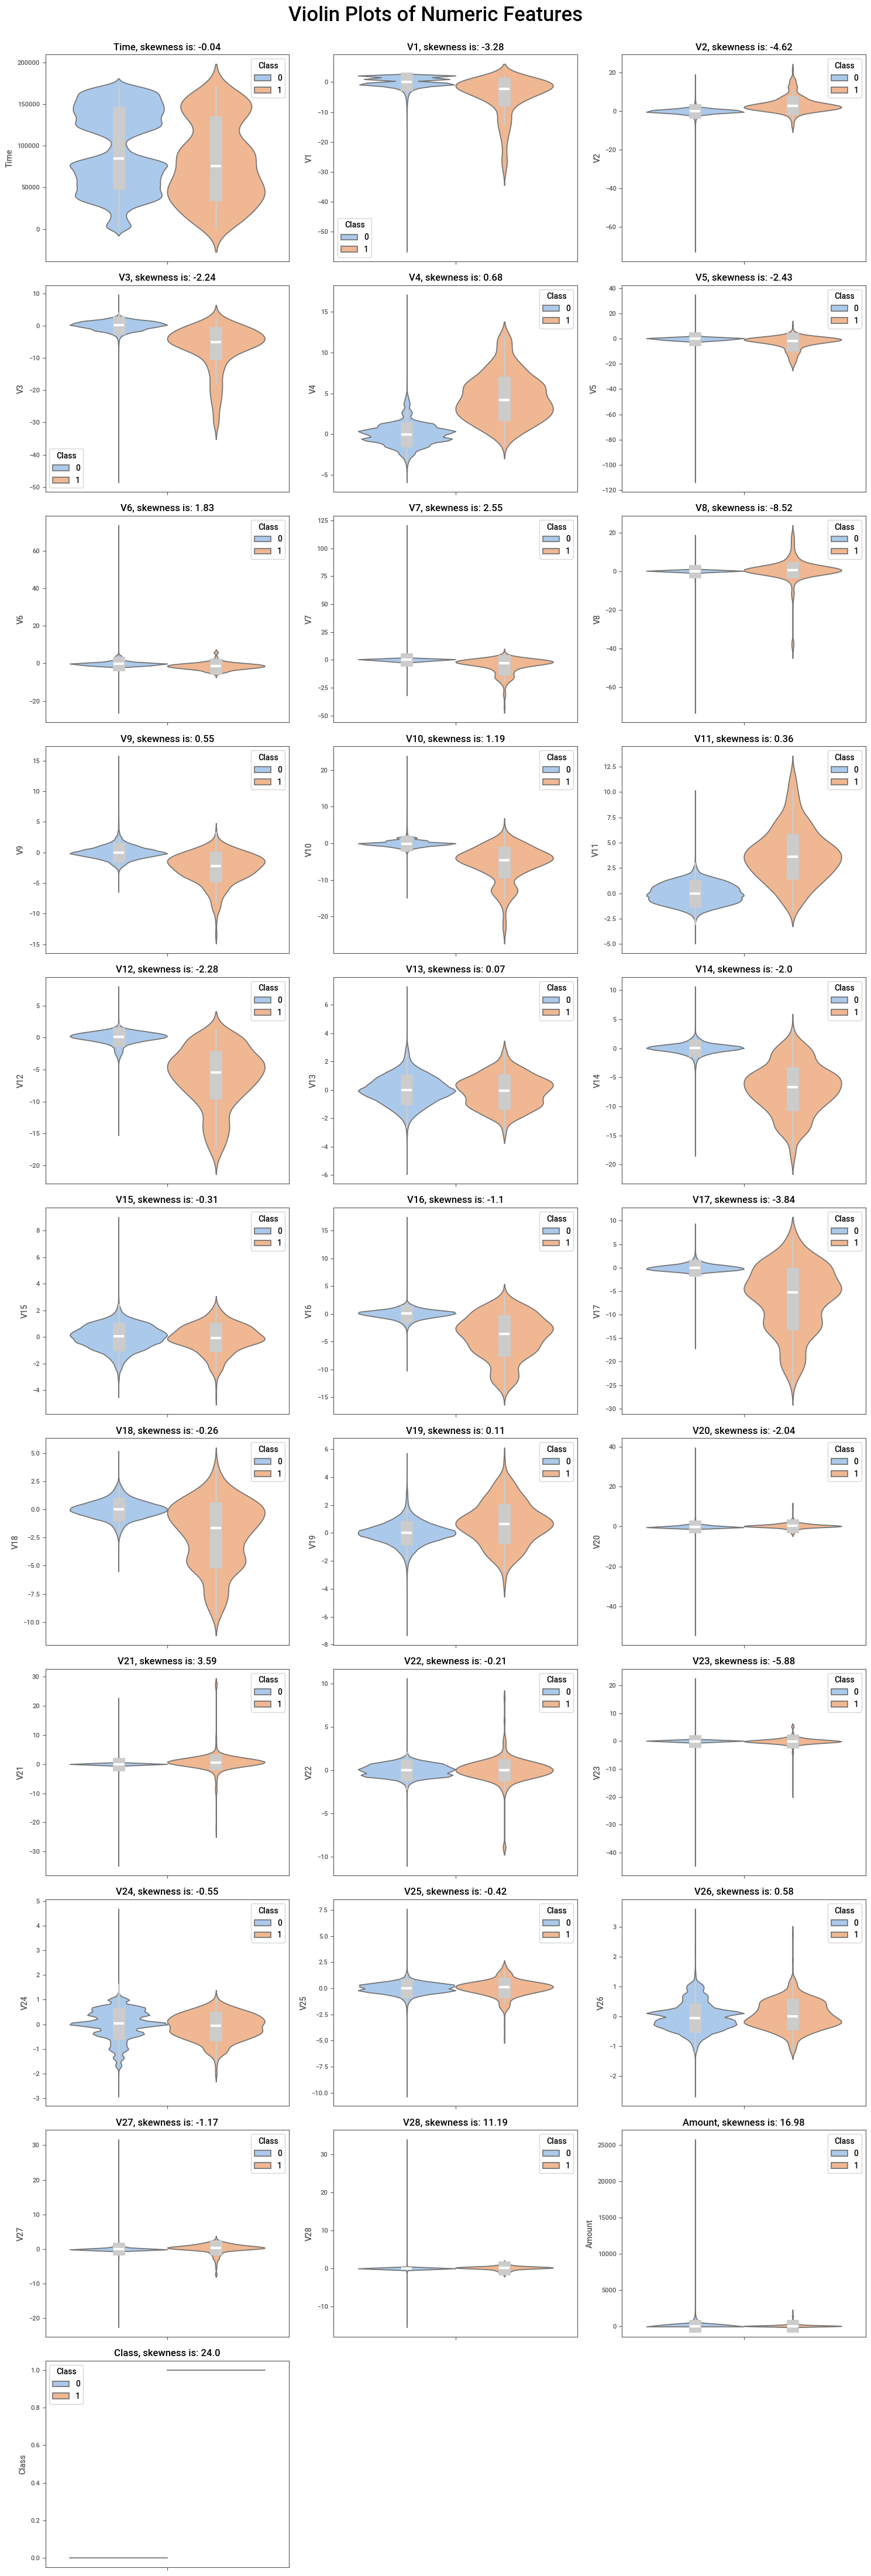

In [12]:
# - Violin Plots for Numeric Columns -
eda.OutlierAnalyser.violinplots_numeric_columns(df4, "Class")

### Problems of Dataset


According to the `sweetviz` report and above boxplots, I have identified the following issues with the dataset. Most of these issues can be found in `Alerts` tab.
| **Issue** | **Approach to Take** | **Reason** |
|--------|------------------|-----------------|
| 773 Duplicate Rows | Drop Duplicates | Exact duplicates of rows (with same numerical values) is highly unlikely. Retaining them hurts model performance |
| No Missing Values | - | - |
| No Incorrect Data Types | - | - |
| Presence of Outliers | - | We will be building ANN, QML, Traditional Tree Models. We shall assume outliers do not pose a severe threat. However, in the case model perfomance is continuously poor, we shall run experiments with outlier handling methods as an attempt to bring up model performance. Such an approach can be removing outliers that are above or below upper and lower bounds respectively. |
| No Invalid / Placeholder Values| - | Extreme Values are common in financial datasets, and obvious placeholders aren't observed in `sweetviz` report |
| High Correlation | - | Maximum correlation is between `Amount` & `V2`: -0.53. This correlation value is safe, and won't require too much of our attention |
| Class Imbalance | SMOTE (Synthetic Minority Oversampling Technique)| There is only 0.02% of dataset (492 transactions) labeled as fraud. Not conducting undersampling / oversampling methods will cause the model to biased towards predicting non-fraud cases (i.e. predict non-fraud across most cases, without capturing true pattern of fraud cases) |


## 5. Finalise Data Cleaner

The `DataCleaner` class from `src/data_processing.py` aims to conduct any jobs, such as dropping duplicates, missing values, fix incorrect data types, manual drop of outliers, drop invalid values, or high correlated features. However, as of now, only dropping of duplicates will be implemented, since it is the only obvious problem flagged out by our EDA.


In [13]:
df5 = dp.DataCleaner.drop_duplicates(df4)

✅ Initial Shape (Before dropping duplicates): (284807, 31)
✅ Dropped 1081 duplicate rows.
✅ Final Shape (After dropping duplicates): (283726, 31)


In [14]:
# - Review Latest Sweetviz Report to Gain Further Insights -
sweet_report = sv.analyze(df5, target_feat="Class", pairwise_analysis="on")
sweet_report.show_html("reports/sweet_report_after_cleaning.html")

                                             |          | [  0%]   00:00 -> (? left)

Report reports/sweet_report_after_cleaning.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


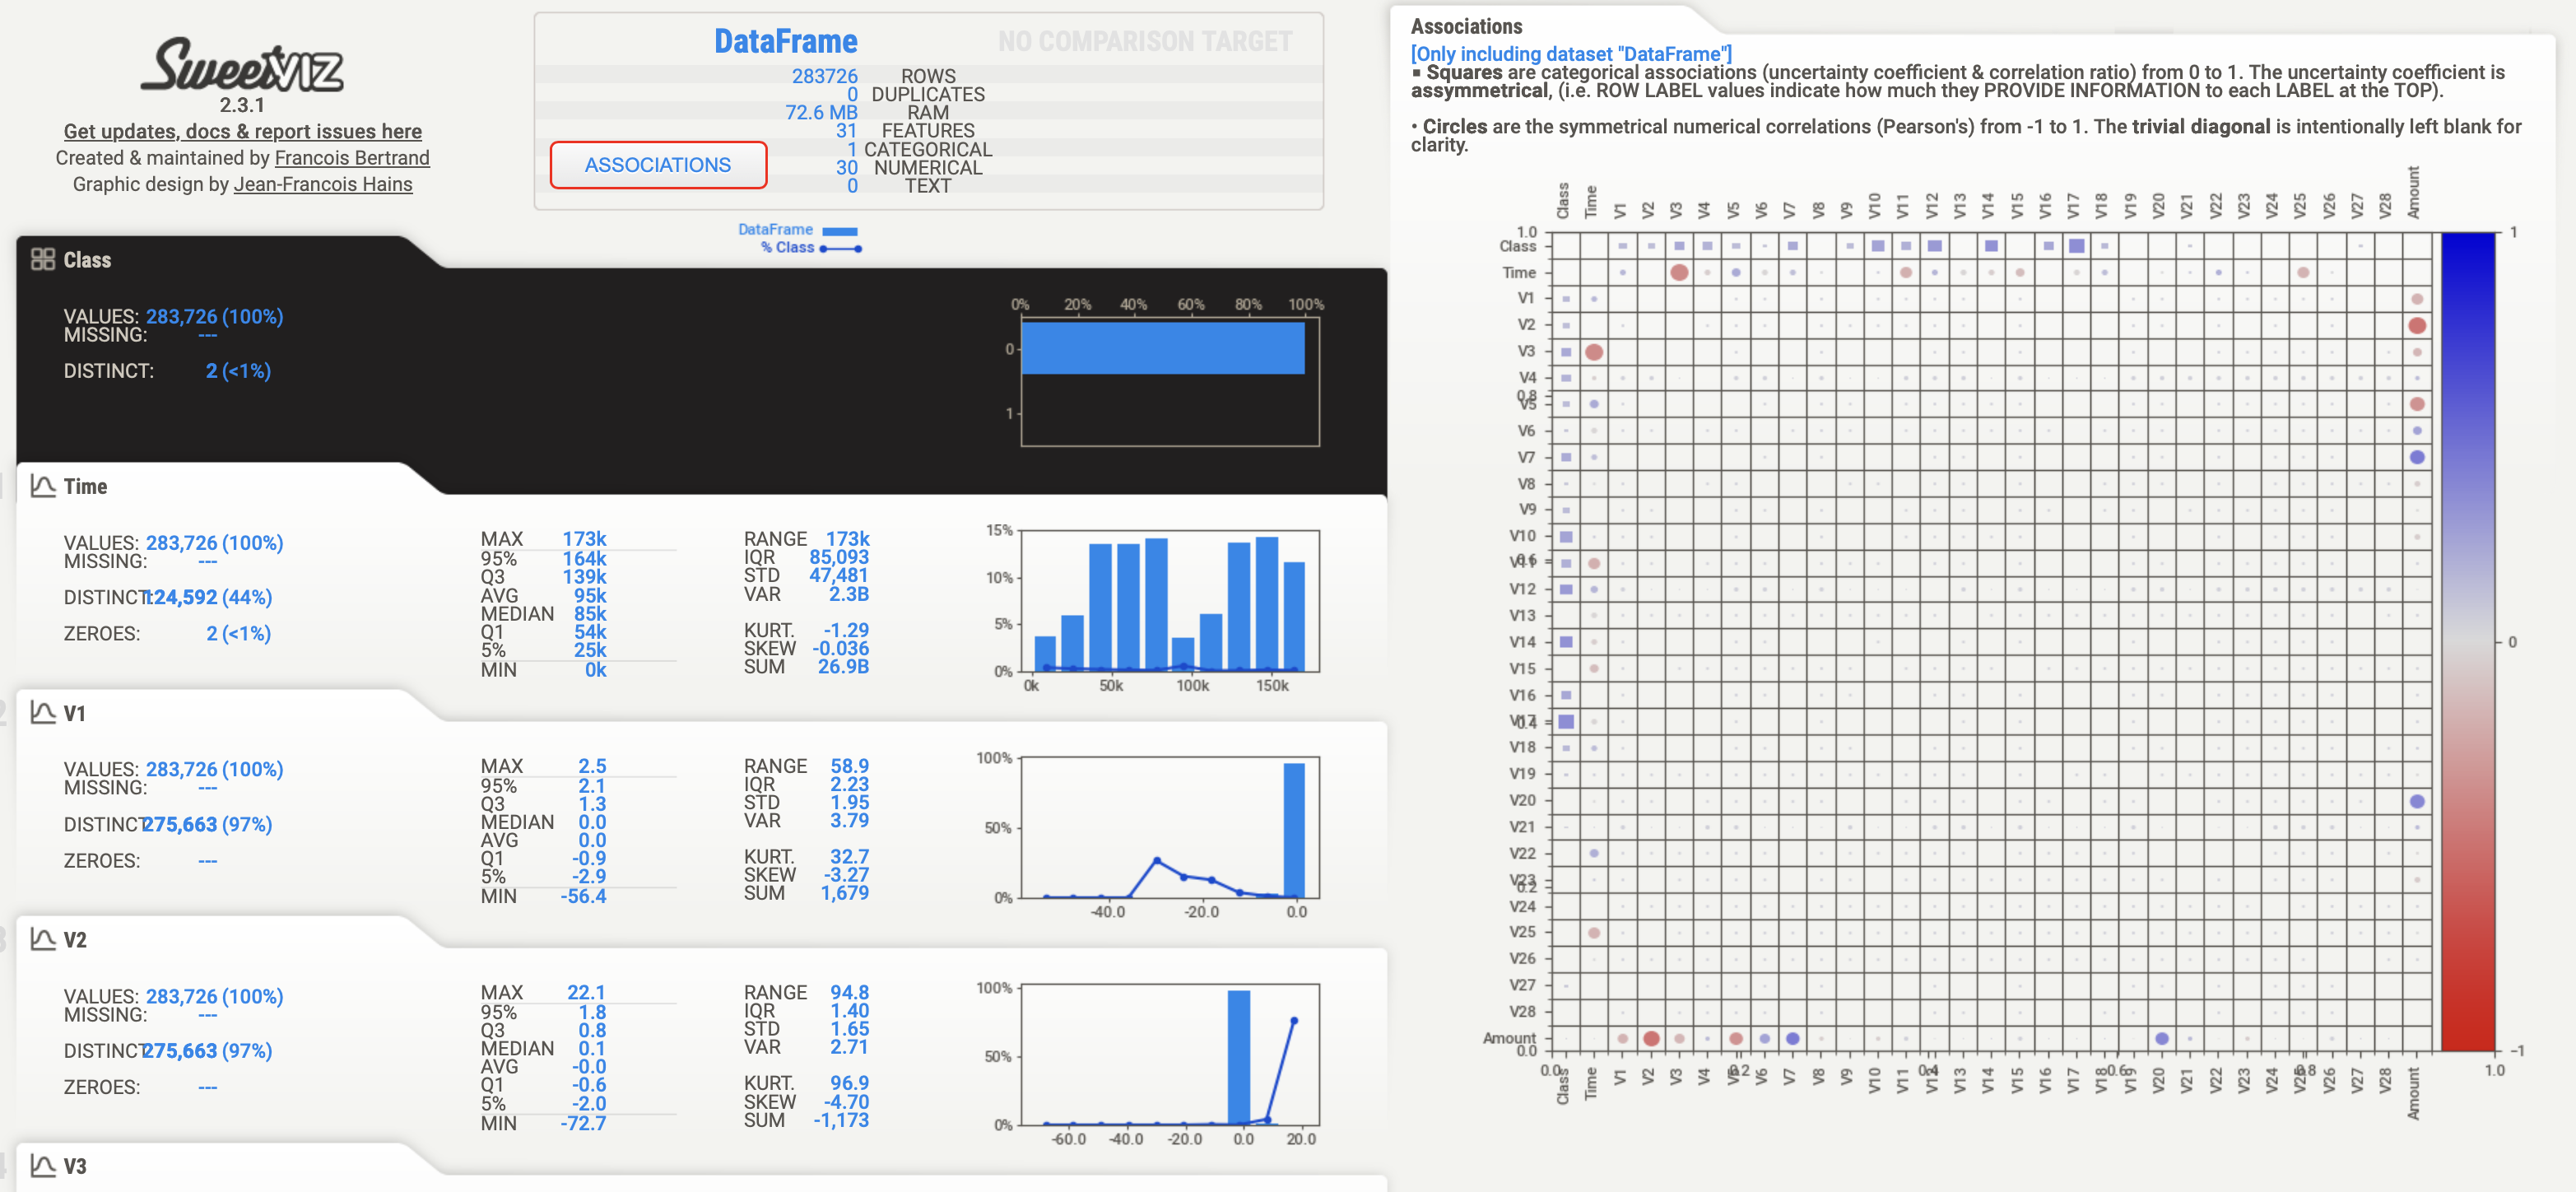

### Final Data Insights

| **Insight**                   | **Approach to Take**                              | **Explanation**                                                                                                                                                                                                                                                                     |
| ----------------------------- | ------------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Class Imbalance               | SMOTE (Synthetic Minority Oversampling Technique) | There is only 0.02% of dataset (492 transactions) labeled as fraud. Not conducting undersampling / oversampling methods will cause the model to biased towards predicting non-fraud cases (i.e. predict non-fraud across most cases, without capturing true pattern of fraud cases) |
| Bimodal `Time` feature        | -                                                 | Fraudlent transactions may occur at a certain timeframe more rampantly, which may be due to the spotting of certain vulnerabilities of fraud detecting systems. Our tree models may be able to detect such patterns                                                                 |
| Heavily Right-Skewed `Amount` | -                                                 | Most transaction amounts are very small. Tree models normally will have effective split conditions to counter skewness / influenced by rare large amounts.                                                                                                                          |
| Hypothesis Testing Redundant  | -                                                 | `V1-V28` are PCA-transformed features, and hypothesis testing won't be useful in deriving business insights.                                                                                                                                                    |


In [15]:
# - Saving to data/processed/ (before split) -
df5.to_csv("data/processed/creditcard_cleaned.csv", index=False)

## 7. Summary

Now that we have outputted the cleaned DataFrame, we can build a simple baseline akin to random guessing, before building traditional and complex models.
